In [1]:
import numpy as np
import pandas as pd
import hf_hydrodata as hf


def get_ma2025_wtd(df, lon_col="longitude", lat_col="latitude"):
    df = df.copy()

    # Initialize output columns
    df["WTD_ma2025_m"] = np.nan
    df["WTD_ma2025_uncertainty_m"] = np.nan

    # Loop through sites
    for idx, row in df.iterrows():

        lat = row[lat_col]
        lon = row[lon_col]

        options_wtd = {
            "dataset": "ma_2025",
            "variable": "water_table_depth",
            "grid": "conus2_wtd.30",
            "latlon_point": [lat, lon],
        }

        wtd = hf.get_gridded_data(options_wtd).squeeze()
        df.loc[idx, "WTD_ma2025_m"] = float(wtd)

        options_unc = {
            "dataset": "ma_2025",
            "variable": "wtd_uncertainty",
            "grid": "conus2_wtd.30",
            "latlon_point": [lat, lon],
        }

        uncertainty = hf.get_gridded_data(options_unc).squeeze()
        df.loc[idx, "WTD_ma2025_uncertainty_m"] = float(uncertainty)

    return df

/Users/5_kp/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import pandas as pd

hf.register_api_pin("zhaoting@ualberta.ca", "0616")

df = pd.read_csv("gwt_validation.csv")

# convert lat/lon to float
df["latitude"] = df["latitude"].astype(float)
df["longitude"] = df["longitude"].astype(float)

print(df)

     boringArray_ID  boringMeta_ID  groundWaterDepth unit  convert to m  \
0                 1            315               6.0   ft       1.82880   
1                 2            317              10.0   ft       3.04800   
2                 3            318              12.0   ft       3.65760   
3                 4            336              31.0    m      31.00000   
4                 6            340              15.0   ft       4.57200   
..              ...            ...               ...  ...           ...   
225             315           1326               8.2   ft       2.49936   
226             316           1327              13.6   ft       4.14528   
227             319           1328              78.2   ft      23.83536   
228             320           1329              28.0   ft       8.53440   
229             327           1330              51.0   ft      15.54480   

     groundWaterDate   longitude   latitude  
0         19971020.0 -115.449000  32.774000  
1      

In [ ]:
import numpy as np
grid = 'conus2_wtd.30'
lat = df.latitude.values
lon = df.longitude.values
dgwt = np.empty(len(lat), dtype=float)
for i in range(len(lat)):
    (x, y) = hf.from_latlon(grid, lat[i], lon[i])
    options = {
        'dataset':'ma_2025',
        'variable': 'water_table_depth',
        'grid': grid,
        'grid_point': [int(x), int(y)],
    }
    dgwt[i] = hf.gridded.get_gridded_data(options)[0][0]

In [ ]:
print(dgwt)

In [3]:
df = get_ma2025_wtd(
    df,
    lon_col="longitude",
    lat_col="latitude"
)

In [4]:
# Save the updated DataFrame to a new CSV file
df.to_csv("site_locations_with_wtd_validation.csv", index=False)

In [3]:
df = pd.read_csv("site_locations_with_wtd_validation.csv")

In [4]:
df

,boringArray_ID,boringMeta_ID,groundWaterDepth,unit,convert to m,groundWaterDate,longitude,latitude,WTD_ma2025_m,WTD_ma2025_uncertainty_m,res_log,res_lin
0,1,315,6.0,ft,1.82880,19971020.0,-115.449000,32.774000,4.280154,2.285619,-0.850329,-2.451354
1,2,317,10.0,ft,3.04800,19980228.0,-118.178000,34.037000,22.576283,14.135419,-2.002414,-19.528283
2,3,318,12.0,ft,3.65760,19980119.0,-118.381000,34.114000,34.923271,70.865334,-2.256346,-31.265671
3,4,336,31.0,m,31.00000,19960111.0,-118.491800,34.011200,NaN,NaN,NaN,NaN
4,6,340,15.0,ft,4.57200,NaN,-121.840200,39.733800,7.305675,10.446406,-0.468701,-2.733675
...,...,...,...,...,...,...,...,...,...,...,...,...
225,315,1326,8.2,ft,2.49936,19970423.0,-111.997311,40.709864,1.358554,1.519295,0.609614,1.140806
226,316,1327,13.6,ft,4.14528,19970310.0,-111.970253,41.219683,8.543544,27.275951,-0.723206,-4.398264
227,319,1328,78.2,ft,23.83536,19970207.0,-111.891061,40.772597,13.039842,33.672131,0.603161,10.795518
228,320,1329,28.0,ft,8.53440,19950428.0,-111.900175,40.587989,16.310143,19.359703,-0.647682,-7.775743


In [10]:
valid = (
    df["convert to m"].notna()
    & (df["convert to m"] > 0)
    & df["WTD_ma2025_m"].notna()
    & (df["WTD_ma2025_m"] > 0)
    & df["WTD_ma2025_uncertainty_m"].notna()
    & (df["WTD_ma2025_uncertainty_m"] != 0)
)

wtd_meas = df.loc[valid, "convert to m"]
wtd_prd = df.loc[valid, "WTD_ma2025_m"]
uncertainty = df.loc[valid, "WTD_ma2025_uncertainty_m"]

res_log = np.log(wtd_meas) - np.log(wtd_prd)
res_lin = wtd_meas - wtd_prd

index1 = res_lin < 100
index2 = res_log < 13

wtd_res_filtered = res_lin[index1]
wtd_res_log_filtered = res_log[index2]


res_log = np.log(wtd_meas) - np.log(wtd_prd)
res_lin = wtd_meas - wtd_prd

index1 = (res_lin < 100)
index2 = (res_log < 13)

wtd_res_filtered = res_lin[index1]
wtd_res_log_filtered = res_log[index2]

print(np.mean(wtd_res_filtered))
print(np.std(wtd_res_filtered))
print(np.mean(wtd_res_log_filtered))
print(np.std(wtd_res_log_filtered))

-1.4189063198476481
9.410095323013726
-0.21932198671098627
0.8168179894427496


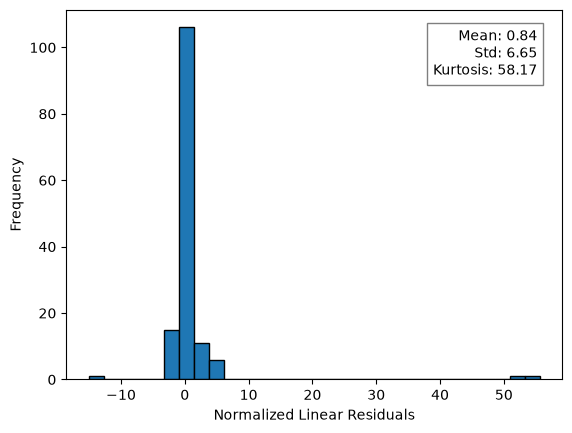

In [23]:
normalized_res_lin = wtd_res_filtered / uncertainty[index1]

import matplotlib.pyplot as plt
from scipy.stats import kurtosis
mean_val = normalized_res_lin.mean()
std_val = normalized_res_lin.std()
kurtosis_val = kurtosis(normalized_res_lin, bias=False) 
plt.hist(normalized_res_lin, bins=30, edgecolor='black')
plt.xlabel("Normalized Linear Residuals")
plt.ylabel("Frequency")
plt.text(0.95, 0.95, f"Mean: {mean_val:.2f}\nStd: {std_val:.2f}\nKurtosis: {kurtosis_val:.2f}", 
         transform=plt.gca().transAxes, 
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.5))
plt.show()

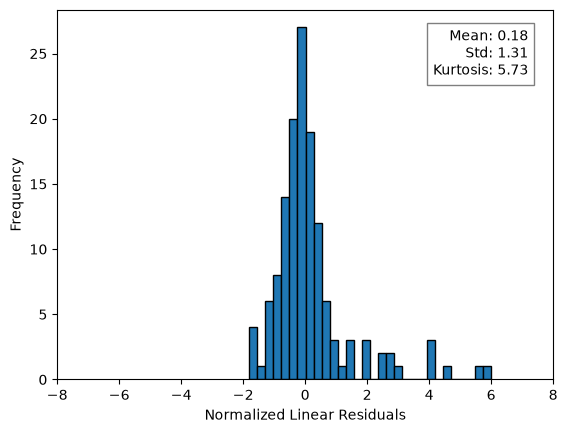

In [25]:
plt.hist(normalized_res_lin[(normalized_res_lin < 10) & (normalized_res_lin > -10)], bins=30, edgecolor='black')
plt.xlabel("Normalized Linear Residuals")
plt.ylabel("Frequency")
# add label of mean, std and kurtosis
mean_val = normalized_res_lin[(normalized_res_lin < 10) & (normalized_res_lin > -10)].mean()
std_val = normalized_res_lin[(normalized_res_lin < 10) & (normalized_res_lin > -10)].std()
kurtosis_val = kurtosis(normalized_res_lin[(normalized_res_lin < 10) & (normalized_res_lin > -10)], bias=False)
plt.text(0.95, 0.95, f"Mean: {mean_val:.2f}\nStd: {std_val:.2f}\nKurtosis: {kurtosis_val:.2f}", 
         transform=plt.gca().transAxes, 
         verticalalignment='top', 
         horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.5))
plt.xlim(-8, 8)
plt.show()

In [19]:
from scipy.stats import kurtosis

print(kurtosis(wtd_res_filtered, bias=False))
print(kurtosis(wtd_res_log_filtered, bias=True))
print(kurtosis(normalized_res_lin[(normalized_res_lin < 10) & (normalized_res_lin > -10)], bias=False))

6.684479786156203
4.211322867584079
5.7288795478658


In [11]:
# add res_log and res_lin to the dataframe
df["res_log"] = res_log
df["res_lin"] = res_lin

df.to_csv("site_locations_with_wtd_validation.csv", index=False)

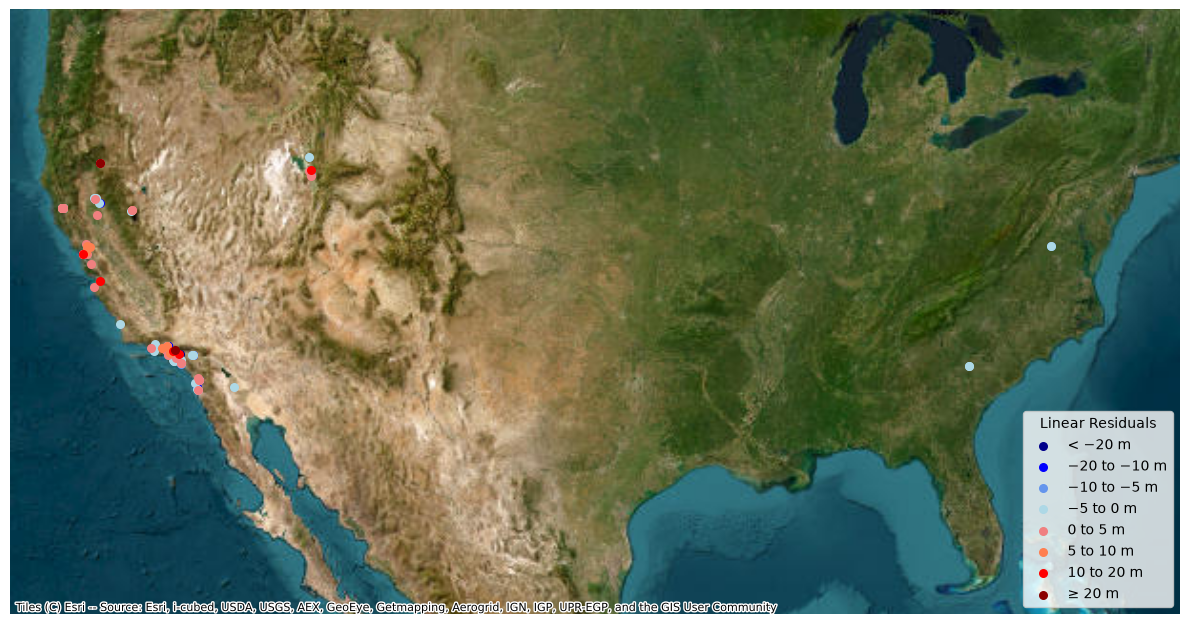

In [5]:
import contextily as ctx
import matplotlib.pyplot as plt
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

# Finer residual categories
conditions = [
    gdf["res_lin"] < -20,
    (gdf["res_lin"] >= -20) & (gdf["res_lin"] < -10),
    (gdf["res_lin"] >= -10) & (gdf["res_lin"] < -5),
    (gdf["res_lin"] >= -5) & (gdf["res_lin"] < 0),
    (gdf["res_lin"] >= 0) & (gdf["res_lin"] < 5),
    (gdf["res_lin"] >= 5) & (gdf["res_lin"] < 10),
    (gdf["res_lin"] >= 10) & (gdf["res_lin"] < 20),
    gdf["res_lin"] >= 20
]

labels = [
    "< −20 m",
    "−20 to −10 m",
    "−10 to −5 m",
    "−5 to 0 m",
    "0 to 5 m",
    "5 to 10 m",
    "10 to 20 m",
    "≥ 20 m"
]

colors = [
    "darkblue",
    "blue",
    "cornflowerblue",
    "lightblue",
    "lightcoral",
    "coral",
    "red",
    "darkred"
]

# Web maps require Web Mercator
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

for label, color in zip(labels, colors):
    category = np.select(conditions, labels, default="")
    subset = gdf_web[category == label]
    subset["color"] = color

    subset.plot(
        ax=ax,
        color=color,
        markersize=30,
        label=label
    )


ax.set_ylim(2.7e6, 5.8e6)
ax.set_xlim(-1.4e7, -0.8e7)

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)


ax.set_axis_off()
legend = ax.legend(title="Linear Residuals", loc="lower right")

plt.tight_layout()
plt.savefig("linear_residuals_map_US.png", dpi=200)


plt.show()

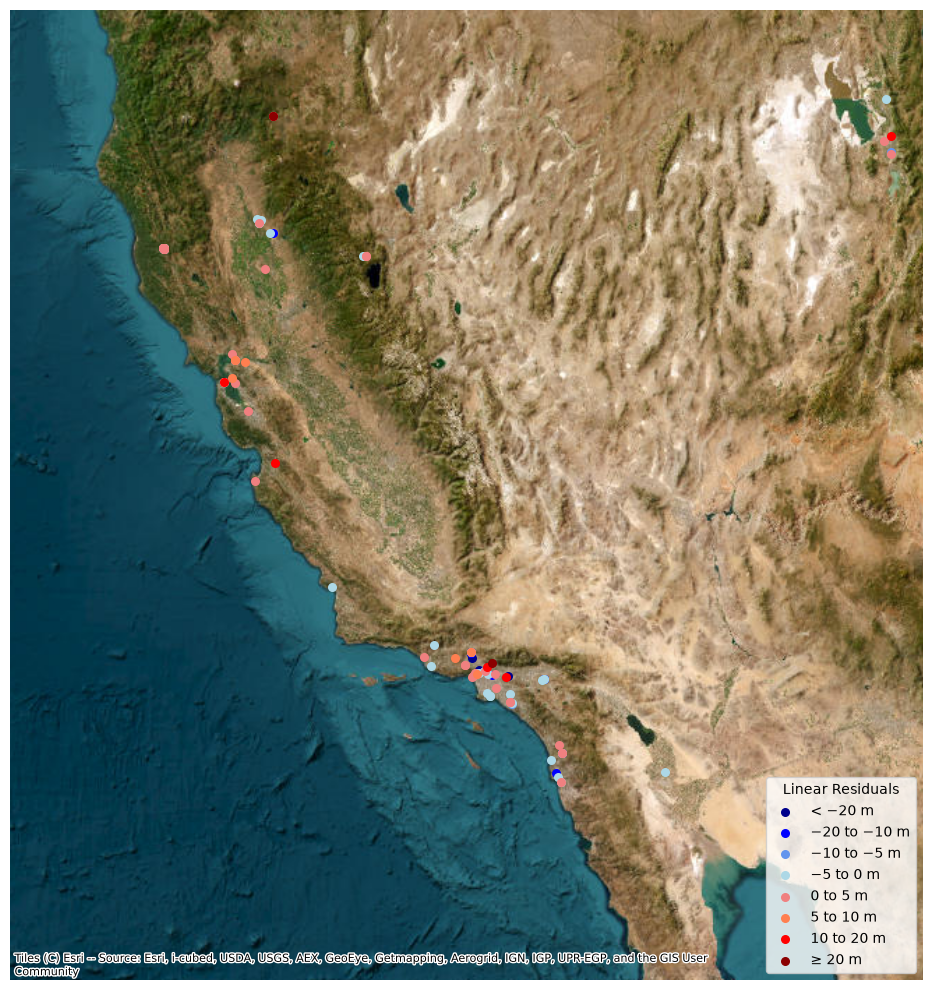

In [6]:
import contextily as ctx
import matplotlib.pyplot as plt
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

# Finer residual categories
conditions = [
    gdf["res_lin"] < -20,
    (gdf["res_lin"] >= -20) & (gdf["res_lin"] < -10),
    (gdf["res_lin"] >= -10) & (gdf["res_lin"] < -5),
    (gdf["res_lin"] >= -5) & (gdf["res_lin"] < 0),
    (gdf["res_lin"] >= 0) & (gdf["res_lin"] < 5),
    (gdf["res_lin"] >= 5) & (gdf["res_lin"] < 10),
    (gdf["res_lin"] >= 10) & (gdf["res_lin"] < 20),
    gdf["res_lin"] >= 20
]

labels = [
    "< −20 m",
    "−20 to −10 m",
    "−10 to −5 m",
    "−5 to 0 m",
    "0 to 5 m",
    "5 to 10 m",
    "10 to 20 m",
    "≥ 20 m"
]

colors = [
    "darkblue",
    "blue",
    "cornflowerblue",
    "lightblue",
    "lightcoral",
    "coral",
    "red",
    "darkred"
]

# Web maps require Web Mercator
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

for label, color in zip(labels, colors):
    category = np.select(conditions, labels, default="")
    subset = gdf_web[category == label]
    subset["color"] = color

    subset.plot(
        ax=ax,
        color=color,
        markersize=30,
        label=label
    )

ax.set_ylim(3.5e6, 5.2e6)
ax.set_xlim(-1.4e7, -1.24e7)

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery, zoom = 6
)

ax.set_axis_off()
legend = ax.legend(title="Linear Residuals", loc="lower right")

plt.tight_layout()
plt.savefig("linear_residuals_map_California.png", dpi=200)

plt.show()

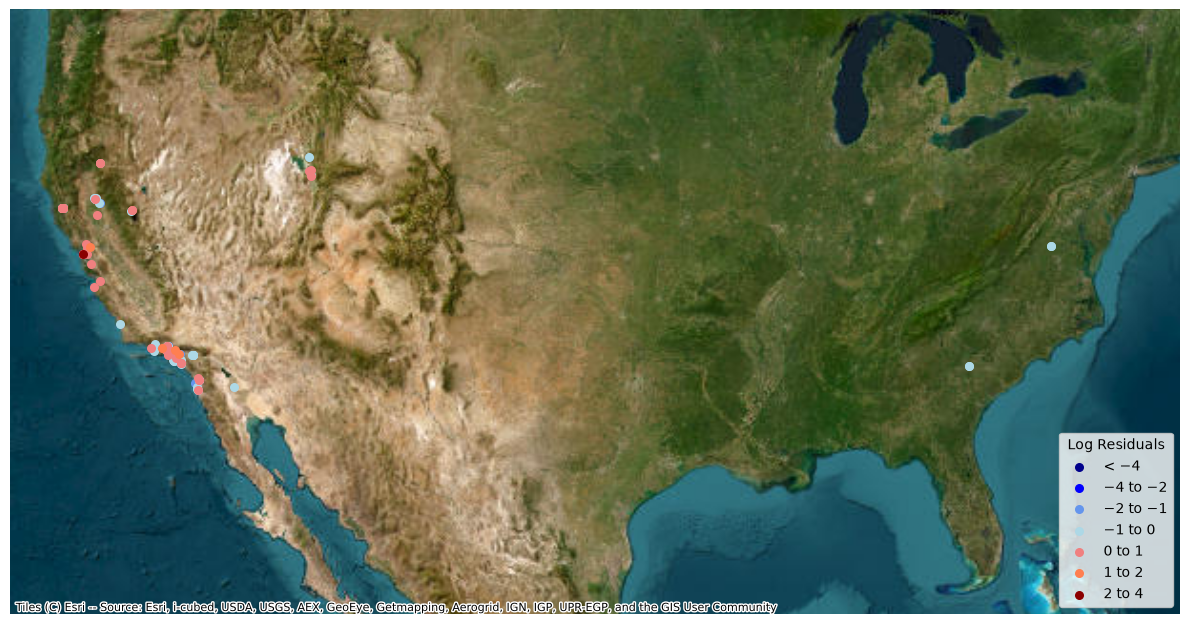

In [7]:
import contextily as ctx
import matplotlib.pyplot as plt
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

# Finer logarithmic residual categories: 2-unit intervals from -10 to 10
conditions = [
    gdf["res_log"] < -4,
    (gdf["res_log"] >= -4) & (gdf["res_log"] < -2),
    (gdf["res_log"] >= -2) & (gdf["res_log"] < -1),
    (gdf["res_log"] >= -1) & (gdf["res_log"] < 0),
    (gdf["res_log"] >= 0) & (gdf["res_log"] < 1),
    (gdf["res_log"] >= 1) & (gdf["res_log"] < 2),
    (gdf["res_log"] >= 2) & (gdf["res_log"] < 4),
    (gdf["res_log"] >= 4) & (gdf["res_log"] < 10),

]

labels = [
    "< −4",
    "−4 to −2",
    "−2 to −1",
    "−1 to 0",
    "0 to 1",
    "1 to 2",
    "2 to 4",
    "4 to 10"
]

colors = [
    "darkblue",
    "blue",
    "cornflowerblue",
    "lightblue",
    "lightcoral",
    "coral",
    "darkred",
]

# Web maps require Web Mercator
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

for label, color in zip(labels, colors):
    category = np.select(conditions, labels, default="")
    subset = gdf_web[category == label]
    subset["color"] = color

    subset.plot(
        ax=ax,
        color=color,
        markersize=30,
        label=label
    )

ax.set_ylim(2.7e6, 5.8e6)
ax.set_xlim(-1.4e7, -0.8e7)

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)

ax.set_axis_off()
legend = ax.legend(title="Log Residuals", loc="lower right")

plt.tight_layout()
plt.savefig("log_residuals_map_US.png", dpi = 200)

plt.show()

C:\Users\5_KP\AppData\Local\Temp\ipykernel_21328\2144192183.py:59: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(


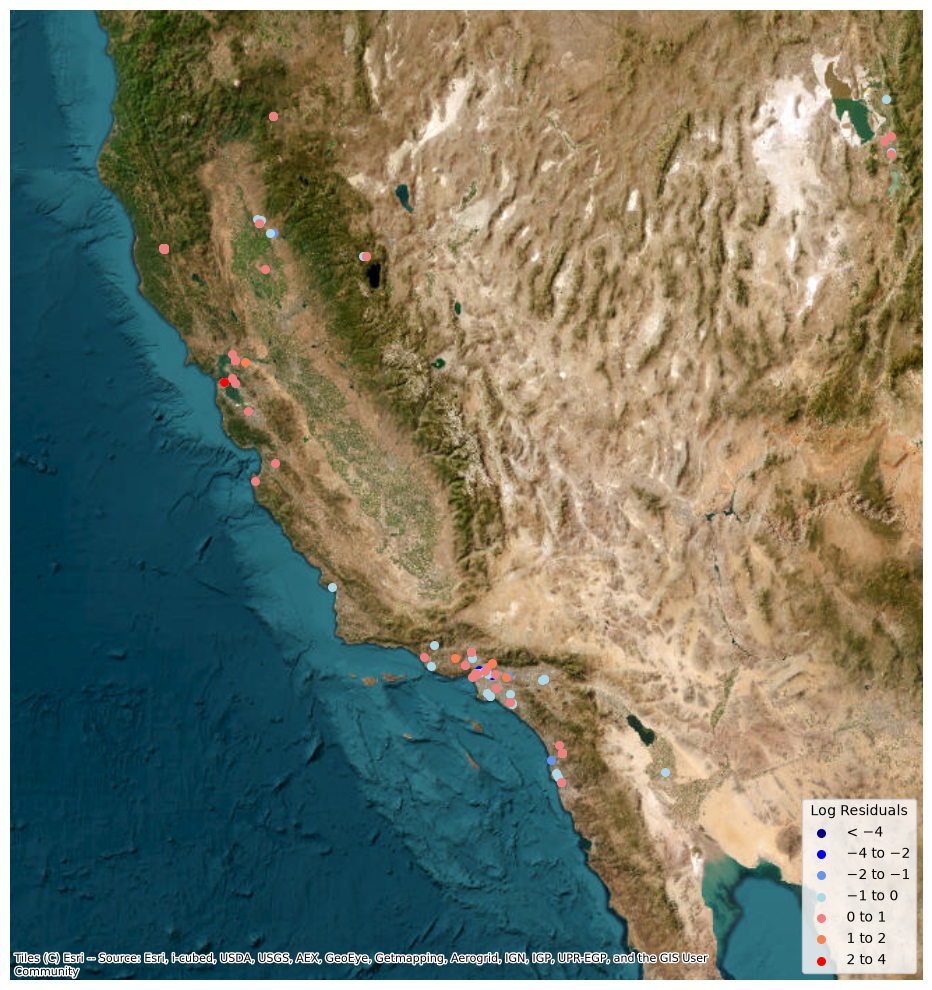

In [8]:
import contextily as ctx
import matplotlib.pyplot as plt
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

# Finer logarithmic residual categories: 2-unit intervals from -10 to 10
conditions = [
    gdf["res_log"] < -4,
    (gdf["res_log"] >= -4) & (gdf["res_log"] < -2),
    (gdf["res_log"] >= -2) & (gdf["res_log"] < -1),
    (gdf["res_log"] >= -1) & (gdf["res_log"] < 0),
    (gdf["res_log"] >= 0) & (gdf["res_log"] < 1),
    (gdf["res_log"] >= 1) & (gdf["res_log"] < 2),
    (gdf["res_log"] >= 2) & (gdf["res_log"] < 4),
    (gdf["res_log"] >= 4) & (gdf["res_log"] < 10),

]

labels = [
    "< −4",
    "−4 to −2",
    "−2 to −1",
    "−1 to 0",
    "0 to 1",
    "1 to 2",
    "2 to 4",
    "4 to 10"
]

colors = [
    "darkblue",
    "blue",
    "cornflowerblue",
    "lightblue",
    "lightcoral",
    "coral",
    "red",
    "darkred",
]

# Web maps require Web Mercator
gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

for label, color in zip(labels, colors):
    category = np.select(conditions, labels, default="")
    subset = gdf_web[category == label]
    subset["color"] = color

    subset.plot(
        ax=ax,
        color=color,
        markersize=30,
        label=label
    )

ax.set_ylim(3.5e6, 5.2e6)
ax.set_xlim(-1.4e7, -1.24e7)

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)

ax.set_axis_off()


legend = ax.legend(title="Log Residuals", loc="lower right")

plt.tight_layout()

plt.savefig("log_residuals_map_California.png", dpi=200)
plt.show()

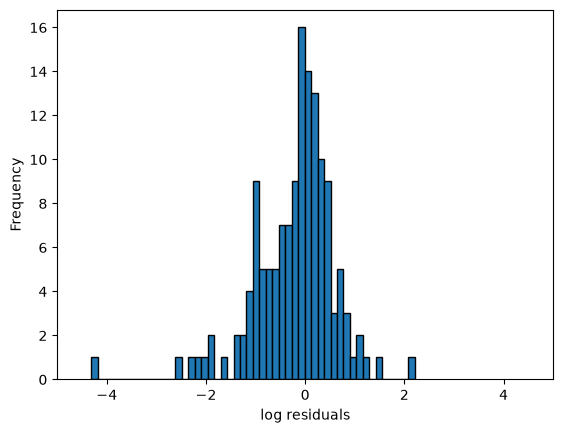

In [14]:
# plot out histogram of the differences
import matplotlib.pyplot as plt

plt.hist(wtd_res_log_filtered, bins=50, edgecolor='black')
# plt.hist(wtd_diff_filtered_std, bins=20)
plt.xlabel("log residuals")
plt.ylabel("Frequency")
plt.xlim(-5, 5)
# plt.title("Histogram of WTD Differences")
plt.show()

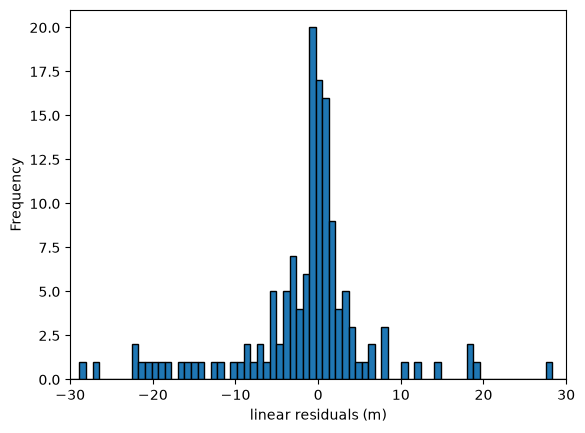

In [13]:
# plot out histogram of the differences
import matplotlib.pyplot as plt

plt.hist(wtd_res_filtered, bins=100, edgecolor='black')
# plt.hist(wtd_diff_filtered_std, bins=20)
plt.xlabel("linear residuals (m)")
plt.ylabel("Frequency")
plt.xlim(-30, 30)
# plt.title("Histogram of WTD Differences")
plt.show()

In [29]:
wtd_prd

0       4.280154
1      22.576283
2      34.923271
4       7.305675
5       1.847959
         ...    
225     1.358554
226     8.543544
227    13.039842
228    16.310143
229    12.729444
Name: WTD_ma2025_m, Length: 146, dtype: float64

In [25]:
normalized_res = wtd_res_filtered/uncertainty


In [30]:
uncertainty

0       2.285619
1      14.135419
2      70.865334
4      10.446406
5       0.801729
         ...    
225     1.519295
226    27.275951
227    33.672131
228    19.359703
229    16.805717
Name: WTD_ma2025_uncertainty_m, Length: 151, dtype: float64

ValueError: supplied range of [-inf, 55.605205499578126] is not finite

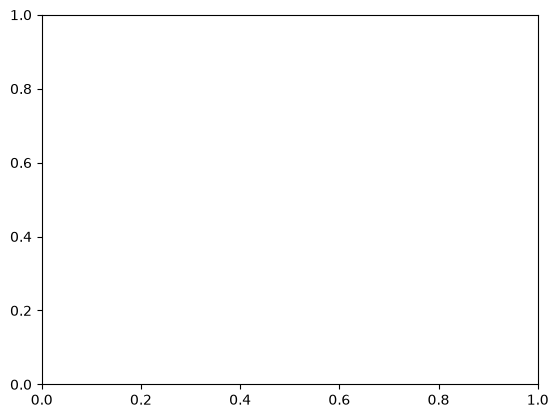

In [24]:
normalized_res = wtd_res_filtered/uncertainty

# plt.hist(wtd_diff_filtered_std, bins=20)

plt.hist(normalized_res, bins=50, edgecolor='black')
plt.xlabel("Uncertainty (m)")
plt.ylabel("Frequency")
plt.show()


In [10]:
# plot out wtd differences vs uncertainty
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(np.abs(wtd_diff_filtered), wtd_diff_filtered_std)
plt.plot([0, 70], [0, 70], 'r--')
plt.xlabel("Absolute Difference (m)")
plt.ylabel("Uncertainty (m)")
plt.xlim(0, 70)
plt.ylim(0, 70)
# plt.title("WTD Differences vs Uncertainty")
plt.show()

NameError: name 'wtd_diff_filtered' is not defined

<Figure size 600x600 with 0 Axes>

In [ ]:
from matplotlib import pyplot as plt

options = {
    "dataset": "ma_2025",
    "variable": "water_table_depth",
    "grid": "conus2_wtd.30",
    "latlng_bounds": [32.5617, -80.1774, 32.8808, -79.7364]
}

wtd_data_bbox = hf.get_gridded_data(options).squeeze()

plt.imshow(wtd_data_bbox, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Water Table Depth (meters)')
plt.show()

In [ ]:
options = {
    "dataset": "ma_2025",
    "variable": "water_table_depth",
    "grid": "conus2_wtd.30",
    "latlng_bounds": [35.1033, -120.631, 35.11, -120.623]
}

wtd_data_bbox = hf.get_gridded_data(options).squeeze()

from matplotlib import pyplot as plt

plt.imshow(wtd_data_bbox, cmap='viridis', origin='lower')
# plot out the site locations on top of the water table depth map with correct projection
plt.colorbar()
plt.title('Water Table Depth (meters)')
plt.show()

In [ ]:
options = {
    "dataset": "ma_2025",
    "variable": "water_table_depth",
    "grid": "conus2_wtd.30",
    "latlng_bounds": [37.8003, -122.33, 37.7023, -122.219]
}

wtd_data_bbox = hf.get_gridded_data(options).squeeze()

from matplotlib import pyplot as plt

plt.imshow(wtd_data_bbox, cmap='viridis', origin='lower')
# plot out the site locations on top of the water table depth map
plt.scatter(df.longitude, df.latitude, c='red', s=10, label='Site Locations')
plt.colorbar()
plt.title('Water Table Depth (meters)')
plt.show()

In [1]:
import pandas as pd

gwt = pd.read_csv("no_dgwt.csv")

lon = float(gwt["longitude"])
lat = float(gwt["latitude"])

In [ ]:
import pandas as pd
import requests

gwt = pd.read_csv("no_dgwt.csv")

def get_usgs_elevation(lon, lat):
    url = "https://epqs.nationalmap.gov/v1/json"
    params = {
        "x": float(lon),
        "y": float(lat),
        "units": "Meters",
        "format": "json"
    }
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()

        elevation = response.json()["value"]
        if elevation is None or elevation == "No Data":
            return None
        return float(elevation)

    except (requests.RequestException, KeyError, ValueError) as e:
        print(f"Elevation query failed at ({lon}, {lat}): {e}")
        return None

gwt["elevation"] = gwt.apply(
    lambda row: get_usgs_elevation(float(row["longitude"]), float(row["latitude"])),
    axis=1
)

Elevation query failed at (-122.2463, 37.7802): 504 Server Error: Gateway Timeout for url: https://epqs.nationalmap.gov/v1/json?x=-122.2463&y=37.7802&units=Meters&format=json
Elevation query failed at (-122.2491, 37.7828): 504 Server Error: Gateway Timeout for url: https://epqs.nationalmap.gov/v1/json?x=-122.2491&y=37.7828&units=Meters&format=json


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import requests

gwt_open_el = pd.read_csv("no_dgwt.csv")

def get_elevation_batch(df, batch_size=100):
    """Query Open-Elevation API in batches for efficiency."""
    elevations = []
    
    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i + batch_size]
        
        locations = [
            {"latitude": float(row["latitude"]), "longitude": float(row["longitude"])}
            for _, row in batch.iterrows()
        ]
        
        try:
            response = requests.post(
                "https://api.open-elevation.com/api/v1/lookup",
                json={"locations": locations},
                timeout=60
            )
            response.raise_for_status()
            results = response.json()["results"]
            elevations.extend([r["elevation"] for r in results])
            print(f"Processed rows {i} to {i + len(batch)}")
            
        except Exception as e:
            print(f"Batch {i}-{i + batch_size} failed: {e}")
            elevations.extend([None] * len(batch))  # Fill failures with None
    
    return elevations

gwt_open_el["elevation"] = get_elevation_batch(gwt_open_el)
print(gwt_open_el[["longitude", "latitude", "elevation"]].head())

Processed rows 0 to 100
Processed rows 100 to 148
   longitude  latitude  elevation
0  -122.2530   37.7847       12.0
1  -122.2463   37.7802        3.0
2  -122.2491   37.7828        5.0
3  -122.2478   37.7829        0.0
4  -122.2506   37.7816        3.0


In [ ]:
gwt.to_csv("USGS_elevation_API.csv", index=False)
gwt_open_el.to_csv("Open_Elevation_API.csv", index=False)

In [ ]:
import pandas as pd
import requests



url = "https://epqs.nationalmap.gov/v1/json"
params = {
    "x": -122.2491,
    "y": 37.7828,
    "units": "Meters",
    "format": "json"
    }




In [ ]:
import pandas as pd
import requests
import time

gwt = pd.read_csv("no_dgwt_R2.csv")

elevations = []

for i, row in gwt.iterrows():
    lon = float(row["longitude"])
    lat = float(row["latitude"])
    
    url = "https://epqs.nationalmap.gov/v1/json"
    params = {
        "x": lon,
        "y": lat,
        "units": "Meters",
        "format": "json"
    }
    
    elevation = None
    for attempt in range(5):
        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            elevation = float(response.json()["value"])
            print(f"Row {i}: ({lon}, {lat}) → {elevation}m")
            break

        except requests.exceptions.HTTPError as e:
            print(f"Row {i} attempt {attempt + 1}/5 failed: {e} — retrying in 10s")
            time.sleep(10)

        except (KeyError, ValueError) as e:
            print(f"Row {i}: parsing error at ({lon}, {lat}): {e}")
            break

    elevations.append(elevation)

gwt["elevation_m"] = elevations


Row 0: (-122.253, 37.7847) → 4.04982996m
Row 1: (-122.2491, 37.7828) → 4.034935951m
Row 2: (-122.2506, 37.7816) → 3.720634699m
Row 3: (-122.2882, 37.7851) → 3.738896132m
Row 4: (-122.2897, 37.7747) → 3.689016819m
Row 5: (-122.3017, 37.8613) → 2.575708389m
Row 6: (-79.7364, 32.8808) → 2.437766314m
Row 7: (-80.0184, 32.6178) → 2.937587023m
Row 8: (-79.9133, 32.731) → 2.174533606m
Row 9: (-88.2449, 47.1664) → 184.577697754m
Row 10: (-87.0511, 41.6598) → 186.497940063m
Row 11: (-87.0607, 41.6569) → 183.397216797m
Row 12: (-87.0619, 41.6597) → 182.910675049m
Row 13: (-122.2477, 37.5558) → 2.994467258m
Row 14: (-120.6254, 35.1098) → 3.471097708m
Row 15: (-120.625, 35.11) → 5.27331543m
Row 16: (-120.6248, 35.1101) → 7.213039875m
Row 17: (-120.6292, 35.1051) → 3.71126318m
Row 18: (-120.6312, 35.104) → 4.024610519m
Row 19: (-120.6278, 35.1053) → 3.098522902m


PermissionError: [Errno 13] Permission denied: 'gwt_with_elevation.csv'

In [3]:
gwt.to_csv("gwt_with_elevation_R2.csv", index=False)
print(gwt[["longitude", "latitude", "elevation_m"]].head())

   longitude  latitude  elevation_m
0  -122.2530   37.7847     4.049830
1  -122.2491   37.7828     4.034936
2  -122.2506   37.7816     3.720635
3  -122.2882   37.7851     3.738896
4  -122.2897   37.7747     3.689017


In [13]:
v1 = pd.read_csv("gwt_with_elevation.csv")
v2 = pd.read_csv("gwt_with_elevation_R2.csv")

df = pd.merge(v1, v2, on = ["travelTimeMeta_ID"], how = "outer", suffixes=("_v1", "_v2"))

df["elevation_m"] = df["elevation_m_v1"].combine_first(df["elevation_m_v2"])
df.drop(columns=["elevation_m_v1", "elevation_m_v2", "longitude_v2", "latitude_v2"], inplace=True)
df["elevation_m"] = df["elevation_m"].apply(lambda x: 0 if x < 0 else x)
df.describe()

,travelTimeMeta_ID,latitude_v1,longitude_v1,elevation_m
count,148.000000,148.000000,148.000000,148.000000
mean,433.270270,35.918402,-104.790001,22.700656
std,404.076214,3.250571,19.659902,56.400208
min,15.000000,28.750000,-122.477000,0.000000
25%,78.750000,32.786500,-122.252100,2.134403
50%,214.500000,35.109750,-120.624950,3.471306
75%,719.750000,37.786900,-80.138800,4.752895
max,1221.000000,47.166400,-79.736400,197.236771


In [20]:
USGS_gwt = pd.read_csv("USGS_Topo_gwt.csv")
Ma_2025_gwt = pd.read_csv("site_locations_with_wtd.csv")

df_gwt = pd.merge(USGS_gwt, Ma_2025_gwt, on = ["travelTimeMeta_ID"], how = "outer", suffixes=("_USGS", "_Ma2025"))
# remane columns elevation_m into gwt_USGS_m
df_gwt.rename(columns={"elevation_m": "gwt_USGS_m"}, inplace=True)
df_gwt["gwt_m"] = df_gwt["gwt_USGS_m"].combine_first(df_gwt["WTD_ma2025_m"])

In [22]:
df_gwt.describe()

,travelTimeMeta_ID,latitude_v1,longitude_v1,gwt_USGS_m,latitude,longitude,WTD_ma2025_m,WTD_ma2025_uncertainty_m,gwt_m
count,1221.000000,148.000000,148.000000,148.000000,1221.000000,1221.000000,1073.000000,1073.000000,1221.000000
mean,611.148239,35.918402,-104.790001,7.216602,36.385446,-103.331283,9.560505,8.135749,9.276396
std,352.835544,3.250571,19.659902,22.423476,4.072882,15.871269,17.131478,13.817287,17.862099
min,1.000000,28.750000,-122.477000,0.000000,25.947300,-122.477000,0.000000,0.000000,0.000000
25%,306.000000,32.786500,-122.252100,2.134403,34.093200,-121.924000,2.937764,1.670754,2.822109
50%,611.000000,35.109750,-120.624950,3.471306,35.981200,-96.941900,4.570000,3.570000,4.359869
75%,916.000000,37.786900,-80.138800,4.752895,37.797800,-89.987300,7.620000,8.533000,7.195535
max,1222.000000,47.166400,-79.736400,184.730728,47.179500,-79.467600,143.606491,147.636795,184.730728
